# Neural Networks: From Neurons to Multi-Layer Perceptrons

This is our last session! Today's topic, neural networks, is behind almost every recent AI breakthrough you've heard of - so let's start with a bit of history.

### A (very) short history

- **1943** - Warren McCulloch (a neuroscientist) and Walter Pitts (a logician) propose the first mathematical model of a biological neuron: a simple unit that fires or doesn't, based on its inputs.
- **1958** - Frank Rosenblatt builds the **Perceptron**, a physical machine that could learn to classify images. It made headlines - the New York Times predicted machines that could "walk, talk, see, write, reproduce itself and be conscious of its existence."
- **1969** - Marvin Minsky and Seymour Papert mathematically prove that a single-layer perceptron **cannot even learn XOR**, a trivially simple pattern. Funding dries up. This kicks off the first "AI winter" - over a decade of stalled progress.
- **1986** - Rumelhart, Hinton, and Williams popularize **backpropagation**, an efficient way to train networks with multiple layers - the fix for the XOR problem above. Multi-layer networks become practical.
- **2012** - A deep network called AlexNet crushes the competition on the ImageNet image recognition challenge, kicking off the modern deep learning boom.
- **2017-today** - The Transformer architecture leads to large language models (GPT, Claude, etc.), and neural networks move from research labs into tools hundreds of millions of people use daily.

The point: the core idea (neurons, layers, learning by adjusting weights) is decades old and surprisingly simple. What really changed since the 1980s is data, and - as we'll see later - **compute**: modern GPUs turned out to be perfectly suited to the kind of math neural networks need, which is a big part of why the field exploded over the last decade.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

---
## 1. The single neuron

A biological neuron receives signals through its dendrites, and if the combined signal is strong enough, it "fires" an output through its axon. McCulloch and Pitts' 1943 model captures this loosely: each input is weighted by how important it is, the weighted inputs are summed up, and the result decides whether (and how strongly) the neuron fires.

$$\hat{y} = f(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)$$

Here $f$ is the **activation function** - it decides how the neuron "fires" given its combined input. Different choices of $f$ give different behavior (more on this below).

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# A single neuron with 2 inputs
w = np.array([2.0, -1.0])
b = 0.5

def neuron(x, w, b):
    z = np.dot(x, w) + b   # weighted sum of inputs, plus bias
    return sigmoid(z)      # squashed into (0, 1) - "how strongly does it fire"

x = np.array([1.0, 1.0])
print("Neuron output:", neuron(x, w, b))

Neuron output: 0.8175744761936437


### Common activation functions

- **Sigmoid**: squashes to (0, 1), classic choice for output of a binary classifier
- **ReLU** ($\max(0, z)$): the default for hidden layers in modern networks - cheap and avoids some training problems
- **Tanh**: like sigmoid but squashes to (-1, 1)

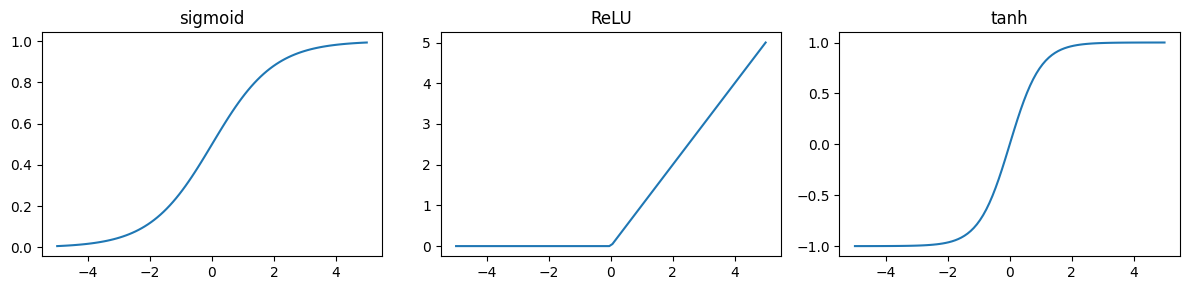

In [3]:
def relu(z):
    return np.maximum(0, z)

z = np.linspace(-5, 5, 100)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(z, sigmoid(z)); axes[0].set_title("sigmoid")
axes[1].plot(z, relu(z)); axes[1].set_title("ReLU")
axes[2].plot(z, np.tanh(z)); axes[2].set_title("tanh")
plt.tight_layout()
plt.show()

---
## 2. The problem that caused an AI winter

A single neuron can only draw a **straight decision boundary** between classes. In 1969, Minsky and Papert showed this makes a single-layer perceptron unable to learn even a simple pattern: **XOR** (exclusive or).

| x1 | x2 | XOR |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 0  |

No single straight line can separate the 1s from the 0s - try drawing one on the plot below. This result was taken (somewhat unfairly, in hindsight) as evidence that neural networks were a dead end, and funding for the field collapsed for over a decade. Let's watch a single perceptron-like neuron fail at this exact task.

Single-neuron (logistic regression) accuracy on XOR: 0.5


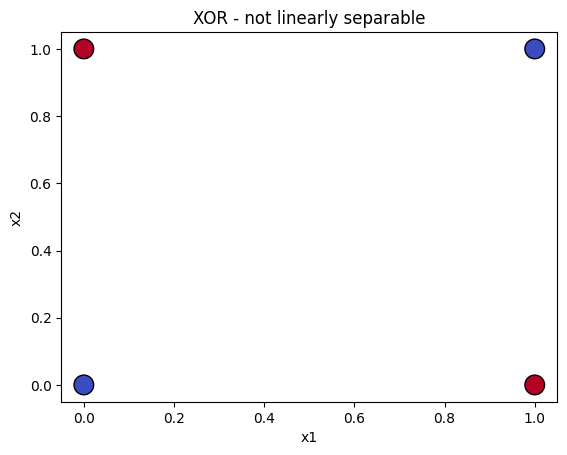

In [4]:
from sklearn.linear_model import LogisticRegression

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

# a single neuron with a sigmoid activation is equivalent to this classifier
clf = LogisticRegression()
clf.fit(X_xor, y_xor)
print("Single-neuron (logistic regression) accuracy on XOR:", clf.score(X_xor, y_xor))

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor, s=200, cmap='coolwarm', edgecolors='k')
plt.title("XOR - not linearly separable")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

Logistic regression cannot do better than chance here. The fix: stack neurons into **layers**. A **hidden layer** of neurons can each learn a different straight-line "cut", and the output neuron combines those cuts into a bent, multi-segment boundary that a single straight line never could. This is exactly what a **Multi-Layer Perceptron (MLP)** does:

```
inputs -> [hidden layer of neurons] -> [output neuron] -> prediction
```

Stacking layers *without* a non-linear activation between them is pointless (it collapses back into one big linear function - just algebra). Non-linearity is what gives the network its power.

---
## 3. Loss function

To train a network, we need a number that tells us how wrong its predictions are. For binary classification, the standard choice is **binary cross-entropy**:

$$L = -\frac{1}{n}\sum_{i=1}^{n} \big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\big]$$

${y}_i$ is the true label (0 or 1), and $\hat{y}_i$ is the predicted probability. The loss is averaged over all n samples.

Intuition: it heavily penalizes confident wrong predictions, and barely penalizes confident correct ones.

In [5]:
def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)  # avoid log(0)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

print(binary_cross_entropy(np.array([1]), np.array([0.99])))  # confident & correct -> low loss
print(binary_cross_entropy(np.array([1]), np.array([0.01])))  # confident & wrong -> high loss

0.01005033585350145
4.605170185988091


---
## 4. What does a network actually look like?

A **Multi-Layer Perceptron (MLP)** stacks neurons into layers:

- an **input layer** (one node per feature - no computation, just entry points)
- one or more **hidden layers** (each neuron connects to every neuron in the previous layer)
- an **output layer** (produces the final prediction)

Every connection (edge) has its own weight. Let's draw a small network - 2 inputs, a hidden layer of 3 neurons, and 1 output - to make this concrete.

<img src="https://towardsdatascience.com/wp-content/uploads/2021/05/1c-GAUGya27McMH2c0uT8vA.png" width="700" style="display: block; margin-left: auto; margin-right: auto;">

**Reading the diagram:** every circle is a neuron, every line is a weighted connection. During training, these weights are exactly what gets adjusted - gradient descent nudges each one, layer by layer (via backpropagation), to reduce the loss. We won't hand-code that process - instead we'll rely on a library to do it (Section 6), and focus on *why* that's not just convenient, but necessary at scale.

---
## 5. Why neural networks took off: GPUs

Training a network mostly means doing **matrix multiplications**, over and over - the forward pass (`X @ W1`, `A1 @ W2`, ...) and the backward pass are both dominated by this one operation, repeated for every layer, every batch of data, every epoch.

A CPU has a handful of powerful cores (built to do many *different* tasks quickly, one after another). A **GPU** has thousands of small, simple cores, purpose-built to do the *same* operation on lots of numbers at once - which is exactly what matrix multiplication needs. This mismatch - CPUs being general-purpose vs. GPUs being embarrassingly parallel - is the main reason networks that would take days to train on CPUs, train in minutes on GPUs.

This is not just a hardware curiosity - it's the historical reason for the timing:
- Networks like AlexNet (2012) only became feasible once researchers started training on GPUs
- Frameworks like **PyTorch** and **TensorFlow** exist largely to make it easy to run your matrix math on a GPU (via NVIDIA's **CUDA**), without writing GPU code yourself
- Companies now buy/rent thousands of GPUs specifically to train larger networks, faster

Let's see the *vectorization* idea (the same principle GPUs take even further) on our own CPU: comparing a naive Python loop to NumPy's vectorized matrix multiplication.

In [6]:
import time

# two decently sized matrices to multiply
A = np.random.randn(200, 200)
B = np.random.randn(200, 200)

# naive, element-by-element Python loop
start = time.time()
result_loop = np.zeros((200, 200))
for i in range(200):
    for j in range(200):
        s = 0.0
        for k in range(200):
            s += A[i, k] * B[k, j]
        result_loop[i, j] = s
loop_time = time.time() - start

# vectorized NumPy matrix multiplication
start = time.time()
result_vec = A @ B
vec_time = time.time() - start

print(f"Naive loop:      {loop_time:.3f} sec")
print(f"Vectorized (@):  {vec_time:.4f} sec")
print(f"Speedup:         {loop_time / vec_time:,.0f}x")

Naive loop:      3.421 sec
Vectorized (@):  0.0005 sec
Speedup:         7,026x


Even on a plain CPU, letting NumPy handle the multiplication in bulk (instead of one number at a time) is orders of magnitude faster. A GPU pushes this same idea much further, by running thousands of these multiplications **simultaneously** in hardware. That's the real "unlock" behind the deep learning boom - not a fundamentally new algorithm, but hardware finally suited to the math these networks were always doing.

---
## 6. Training a network: `MLPClassifier` in scikit-learn

`scikit-learn` has a ready-made `MLPClassifier` with the exact same `fit` / `predict` / `score` interface you already used for `LinearRegression`, `Lasso`, and `KMeans`.

Note: in real-world work, `MLPClassifier` is rarely used - libraries like **Keras** and **PyTorch** are the industry standard for neural networks (better performance, GPU support, more flexibility, as we just discussed). But for a quick job, or for learning, `MLPClassifier` is a handy shortcut.

In [7]:
from sklearn.neural_network import MLPClassifier

sk_mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', max_iter=5000, random_state=0)
sk_mlp.fit(X_xor, y_xor)

print("scikit-learn MLP accuracy on XOR:", sk_mlp.score(X_xor, y_xor))
print("Predictions:", sk_mlp.predict(X_xor))

scikit-learn MLP accuracy on XOR: 1.0
Predictions: [0 1 1 0]


Four lines of code, and the network solves XOR - the exact problem that stumped researchers in 1969.

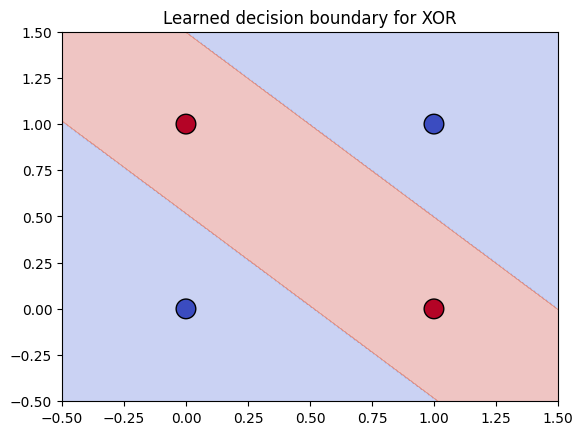

In [8]:
# Visualize the decision boundary the network learned
def plot_decision_boundary(model, X, y, title=""):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=200, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(sk_mlp, X_xor, y_xor, title="Learned decision boundary for XOR")

Notice the boundary isn't one straight line - it bends (it's made of several straight segments stitched together, since we used ReLU hidden units). That bending is the non-linearity from the hidden layer at work: a single neuron can only ever draw one straight line, but stacking neurons lets the network combine several straight cuts into a boundary that wraps around both classes.

---
## 7. Where do neural networks fit?

Neural networks are not tied to one category - they are a flexible *tool* that can be used for both:

- **Supervised learning**: classification (is this cell cancerous?) or regression (predict gene expression level) - what we just did.
- **Unsupervised learning**: e.g. an **autoencoder** is a network trained to compress and reconstruct its own input, with no labels at all.

So "supervised vs. unsupervised" is a distinction about the *task*, not the *model*. A neural network can be pointed at either.

### So... when should I actually reach for a neural network?

As a rule of thumb: if you have **a lot of data** and **access to a GPU**, a neural network is often a reasonable default - it tends to keep improving as you feed it more data, in a way simpler models plateau on.

The main drawback is **interpretability**. A `LinearRegression` model gives you a clean coefficient per feature - you can say exactly *why* it predicted what it did. A neural network with millions of weights spread across many layers doesn't give you that for free; it's much closer to a "black box." This matters a lot in regulated or high-stakes settings (medicine, credit scoring, hiring) where you may need to explain a decision.

This isn't a dead end, though - it's an active area of research, broadly called **explainable AI (XAI)**, with tools like:
- **SHAP** and **LIME** - estimate how much each input feature pushed a specific prediction up or down
- **Attention maps / saliency maps** - highlight which parts of the input (e.g. which pixels, which words) the network "focused on"

So the trade-off is real, but not absolute - you can often get *some* interpretability back, at the cost of extra work.

---
## 8. So what are those fancy "transformers" and "CNNs" and "RNNs" I keep hearing about?

The main thing to understand is that there are many different neural network architectures, each suited to different kinds of data. The MLP we just built is a "fully connected" network - every neuron in one layer connects to every neuron in the next. This works well for tabular data, but not so well for sequences (like text) or images.

There are CNNs (convolutional neural networks) for images, RNNs (recurrent neural networks) for sequences, and now **Transformers** for sequences too - but with a different approach than RNNs. Transformers use a mechanism called **attention** to weigh the importance of different parts of the input sequence when making predictions, which allows them to capture long-range dependencies more effectively than RNNs.

You could think of a special architecture yourself if you wanted to - the key is that the architecture (how neurons are connected) is separate from the training algorithm (backpropagation, gradient descent, etc.). The architecture is what makes a network good at images vs. sequences vs. tabular data. Of course using existing architectures is usually easier than inventing your own, but the point is that the architecture is a design choice, not a fundamental limitation.

Many people invest a lot of time in architecture design, and the field is still evolving rapidly. The Transformer architecture, for example, has led to huge advances in natural language processing and is the basis for models like GPT-3.

---
## 🪐 Zorgian Xenobiology Exercise

**Time**: ~20 minutes

### Background
Zorgian xenobiologists are cataloguing newly discovered creatures on a moon of their planet. For each creature they measured two traits:

- `claw_length` (cm)
- `sprint_speed` (m/s)

and labeled each creature as **predator** (1) or **prey** (0). Early attempts with logistic regression gave poor results - the biologists suspect the boundary between predator and prey is not a straight line (fast, small-clawed ambush hunters exist alongside slow, big-clawed hunters).

### Task
1. Use the `make_zorgian_creatures` function below to generate a labeled dataset.
2. Split it into train/test sets (you did this in the regression session).
3. Train an `MLPClassifier` on the training set.
4. Report its accuracy on the test set.
5. Plot the decision boundary (reuse `plot_decision_boundary` from Section 6).
6. Try changing `hidden_layer_sizes`. Does a bigger hidden layer help? Does it ever hurt?

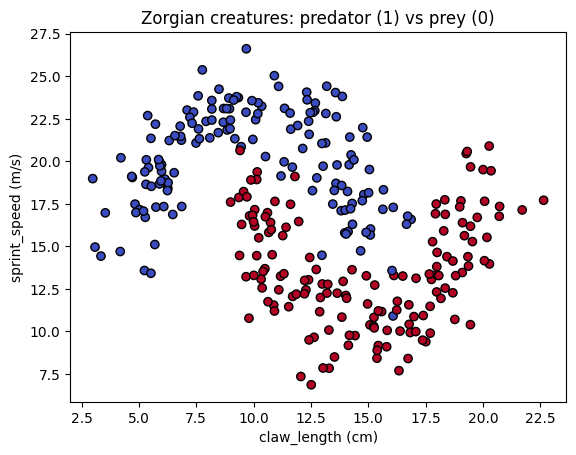

In [9]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons

def make_zorgian_creatures(n_samples=300, noise=0.2, random_state=0):
    """Generates a toy (claw_length, sprint_speed) dataset with a curved
    predator/prey boundary - inspired by make_moons."""
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    claw_length = X[:, 0] * 5 + 10       # rescale to a plausible cm range
    sprint_speed = X[:, 1] * 8 + 15      # rescale to a plausible m/s range
    return np.column_stack([claw_length, sprint_speed]), y

X_creatures, y_creatures = make_zorgian_creatures()

plt.scatter(X_creatures[:,0], X_creatures[:,1], c=y_creatures, cmap='coolwarm', edgecolors='k')
plt.xlabel("claw_length (cm)"); plt.ylabel("sprint_speed (m/s)")
plt.title("Zorgian creatures: predator (1) vs prey (0)")
plt.show()

In [10]:
# Your code here

---
## References
- [3Blue1Brown: But what is a neural network?](https://www.youtube.com/watch?v=aircAruvnKk) - excellent visual intuition
- [scikit-learn MLPClassifier docs](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [NVIDIA: What is CUDA?](https://blogs.nvidia.com/blog/what-is-cuda-2/) - why GPUs and parallel matrix math go together
- [Google Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course/neural-networks) - a great free resource for learning the basics of ML and Neural Networks